# Классификация мест залежей нефти и газа

In [65]:
# 1. Импортируем библиотеки

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)

# Для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [66]:
# 2. Загрузка данных

train_df = pd.read_csv('data/train_oil.csv')
test_df = pd.read_csv('data/oil_test.csv')

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)

display(train_df.head())
display(test_df.head())

Train shape: (309, 20)
Test shape: (133, 19)


,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,53.2287,-115.8008,NUMEROUS,ONSHORE,OIL,UNKNOWN,FORELAND,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0


,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ABU GHARADIG,BAHARIYA,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.7422,28.4925,GUPCO,GAS-CONDENSATE,MATURE PRODUCTION,RIFT,10282,CRETACEOUS,SANDSTONE,745.0,144.0,10.0,8.0
1,ABU MADI-EL QARA,ABU MADI (LEVEL III),EGYPT,AFRICA,NILE DELTA,STRIKE-SLIP/TRANSTENSION/SHALE/EVAPORITE/BASEM...,31.4382,31.3616,IEOC,GAS,DECLINING PRODUCTION,WRENCH/DELTA,10499,NEOGENE,SANDSTONE,509.0,410.0,20.0,300.0
2,ALIBEKMOLA,KT I,KAZAKHSTAN,FORMER SOVIET UNION,CASPIAN NORTH,COMPRESSION/EVAPORITE,48.4740,57.6667,KAZAKHOIL AKTOBE,OIL,DEVELOPING,SUB-SALT/FORELAND,6000,CARBONIFEROUS,LIMESTONE,300.0,105.0,10.0,20.0
3,ALWYN NORTH,BRENT (BRENT EAST),UK,EUROPE,NORTH SEA NORTHERN,INVERSION/COMPRESSION/EXTENSION,60.7833,1.7333,TOTAL,OIL,NEARLY DEPLETED,RIFT,9790,JURASSIC,SANDSTONE,886.0,344.0,17.0,500.0
4,ANKLESHWAR,ANKLESHWAR (HAZAD-ARDOL),INDIA,FAR EAST,CAMBAY,STRIKE-SLIP/TRANSPRESSION/BASEMENT-I,21.6000,72.9167,ONGC,OIL,MATURE PRODUCTION,WRENCH/RIFT,2950,PALEOGENE,SANDSTONE,670.0,0.0,21.0,250.0


In [67]:
# 3. Первичный анализ данных(info)

print('Информация о train:')
train_df.info()

Информация о train:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      309 non-null    object 
 1   Reservoir unit                  309 non-null    object 
 2   Country                         282 non-null    object 
 3   Region                          271 non-null    object 
 4   Basin name                      271 non-null    object 
 5   Tectonic regime                 309 non-null    object 
 6   Latitude                        282 non-null    float64
 7   Longitude                       279 non-null    float64
 8   Operator company                309 non-null    object 
 9   Onshore/Offshore                309 non-null    object 
 10  Hydrocarbon type                309 non-null    object 
 11  Reservoir status                309 non-null    object 
 12  Structural setti

In [68]:
# 3. Первичный анализ данных(пропуски)

print('\nПропуски в train:')
print(train_df.isna().sum().sort_values(ascending=False))


Пропуски в train:
Region                            38
Basin name                        38
Longitude                         30
Country                           27
Latitude                          27
Field name                         0
Depth                              0
Porosity                           0
Thickness (net pay average ft)     0
Thickness (gross average ft)       0
Lithology                          0
Reservoir period                   0
Hydrocarbon type                   0
Structural setting                 0
Reservoir status                   0
Reservoir unit                     0
Onshore/Offshore                   0
Operator company                   0
Tectonic regime                    0
Permeability                       0
dtype: int64


In [69]:
# 3. Первичный анализ данных(целевые признаки)

print('\nРаспределение целевого признака:')
print(train_df['Onshore/Offshore'].value_counts())


Распределение целевого признака:
Onshore/Offshore
ONSHORE             218
OFFSHORE             86
ONSHORE-OFFSHORE      5
Name: count, dtype: int64


__Вывод 3. персичного анализа данных:__
- Датасет содержит числовые и категориальные признаки.
- В некоторых столбцах есть пропуски.
- Целевой признак содержит 3 класса, но по условию нужна бинарная классификация.
- Класс 'ONSHORE-OFFSHORE' будет удалён как неоднозначный.

In [70]:
# 4. Очистка целевого признака (бинарная классификация)

# Оставляем только бинарные классы
train_df = train_df[train_df['Onshore/Offshore'].isin(['ONSHORE', 'OFFSHORE'])].copy()

print('Размер train после удаления неоднозначного класса:', train_df.shape)
print(train_df['Onshore/Offshore'].value_counts())

Размер train после удаления неоднозначного класса: (304, 20)
Onshore/Offshore
ONSHORE     218
OFFSHORE     86
Name: count, dtype: int64


__Вывод после 4. очистки целевого признака__
- Для корректной постановки задачи бинарной классификации удалены записи с классом 'ONSHORE-OFFSHORE'.
- После очистки остаются только классы ONSHORE и OFFSHORE.

In [71]:
# 5. Разделение признаков и целевой переменной

X = train_df.drop(columns=['Onshore/Offshore'])
y = train_df['Onshore/Offshore']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (304, 19)
y shape: (304,)


In [72]:
# 6. Определение числовых и категориальных признаков

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = [col for col in X.columns if col not in numeric_features]

print('Числовые признаки:', numeric_features)
print('Категориальные признаки:', categorical_features)

Числовые признаки: ['Latitude', 'Longitude', 'Depth', 'Thickness (gross average ft)', 'Thickness (net pay average ft)', 'Porosity', 'Permeability']
Категориальные признаки: ['Field name', 'Reservoir unit', 'Country', 'Region', 'Basin name', 'Tectonic regime', 'Operator company', 'Hydrocarbon type', 'Reservoir status', 'Structural setting', 'Reservoir period', 'Lithology']


In [73]:
# 7. Train / Validation split (разделение на обучение и валидацию)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_valid:', X_valid.shape)

X_train: (243, 19)
X_valid: (61, 19)


In [74]:
# 8. Предобработка данных (Для KNN)

numeric_transformer_knn = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_knn = ColumnTransformer(transformers=[
    ('num', numeric_transformer_knn, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [75]:
# 8. Предобработка данных (Для дерева и ансамбля)

numeric_transformer_tree = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor_tree = ColumnTransformer(transformers=[
    ('num', numeric_transformer_tree, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

__Вывод после 8. Предобработка данных__
- Для числовых признаков пропуски заполняются медианой.
- Для категориальных признаков пропуски заполняются наиболее частым значением.
- Для KNN применено масштабирование, так как метод чувствителен к масштабу признаков.
- Для деревьев и ансамблей масштабирование не требуется.

In [76]:
# 9. Обучение нескольких моделей и подбор гиперпараметров (KNN)
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_knn),
    ('model', KNeighborsClassifier())
])

knn_params = {
    'model__n_neighbors': [3, 5, 7, 9],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_params,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print('Лучшие параметры KNN:', knn_grid.best_params_)
print('Лучший CV score (F1 macro):', knn_grid.best_score_)

Лучшие параметры KNN: {'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'distance'}
Лучший CV score (F1 macro): 0.8082749313777351


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.75340521 0.75340521 0.75949876 0.76391938 0.75943552 0.75943552
 0.78173831 0.78173831        nan 0.80827493        nan 0.79440043
        nan 0.79322491        nan 0.79743983]
  warnings.warn(


In [77]:
# 9. Обучение нескольких моделей и подбор гиперпараметров (Decision Tree)

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('model', DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

dt_params = {
    'model__max_depth': [None, 5, 10, 15],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_params,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print('Лучшие параметры Decision Tree:', dt_grid.best_params_)
print('Лучший CV score (F1 macro):', dt_grid.best_score_)

Лучшие параметры Decision Tree: {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}
Лучший CV score (F1 macro): 0.782130130241786


In [78]:
# 9. Обучение нескольких моделей и подбор гиперпараметров (Random Forest)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Лучшие параметры Random Forest:", rf_grid.best_params_)
print("Лучший CV score (F1 macro):", rf_grid.best_score_)


Лучшие параметры Random Forest: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Лучший CV score (F1 macro): 0.8680691889319405


In [79]:
# 10. Сравнение моделей на validation

models = {
    "KNN": knn_grid.best_estimator_,
    "Decision Tree": dt_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_valid)

    f1 = f1_score(y_valid, y_pred, average="macro")
    precision = precision_score(y_valid, y_pred, average="macro")
    recall = recall_score(y_valid, y_pred, average="macro")

    results.append({
        "Model": name,
        "F1_macro": f1,
        "Precision_macro": precision,
        "Recall_macro": recall
    })

results_df = pd.DataFrame(results).sort_values(by="F1_macro", ascending=False)
display(results_df)

,Model,F1_macro,Precision_macro,Recall_macro
1,Decision Tree,0.808897,0.795833,0.832219
0,KNN,0.796440,0.845238,0.771390
2,Random Forest,0.788194,0.801449,0.778075


__Вывод после 10. Сравнение моделей на validation__
- Сравнение моделей проводится по F1_macro, так как классы немного несбалансированы.
- Основной критерий выбора лучшей модели — максимальное значение F1_macro на validation.

In [80]:
# 11. Выбор лучшей модели

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Лучшая модель:", best_model_name)

Лучшая модель: Decision Tree


__Вывод после 11. Выбор лучшей модели__
- По результатам сравнения лучшей моделью выбрана: Decision Tree.
- Выбор сделан на основе максимального значения F1_macro на validation-выборке.
- F1_macro выбран как основная метрика, так как важно учитывать качество классификации обоих классов.

Classification Report:
              precision    recall  f1-score   support

    OFFSHORE       0.67      0.82      0.74        17
     ONSHORE       0.93      0.84      0.88        44

    accuracy                           0.84        61
   macro avg       0.80      0.83      0.81        61
weighted avg       0.85      0.84      0.84        61



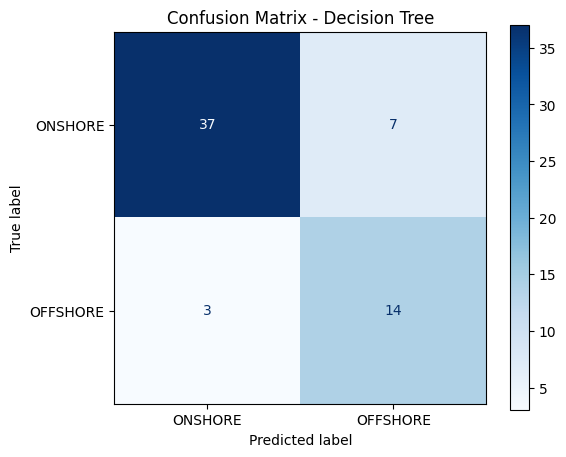

In [81]:
# 12. Детальная оценка лучшей модели

y_valid_pred = best_model.predict(X_valid)

print("Classification Report:")
print(classification_report(y_valid, y_valid_pred))

cm = confusion_matrix(y_valid, y_valid_pred, labels=["ONSHORE", "OFFSHORE"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ONSHORE", "OFFSHORE"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

__Вывод после 12. Детальная оценка лучшей модели__
- Матрица ошибок показывает количество правильных и ошибочных предсказаний по каждому классу.
- Classification Report позволяет оценить Precision, Recall и F1-score отдельно по классам.

In [82]:
# 13. Обучение лучшей модели на всём train

best_model.fit(X, y)
final_model = best_model

In [83]:
# 14. Предсказание на тестовых данных

test_predictions = final_model.predict(test_df)

submission = test_df.copy()
submission["Onshore/Offshore"] = test_predictions

display(submission.head())
print(submission["Onshore/Offshore"].value_counts())

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability,Onshore/Offshore
0,ABU GHARADIG,BAHARIYA,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.7422,28.4925,GUPCO,GAS-CONDENSATE,MATURE PRODUCTION,RIFT,10282,CRETACEOUS,SANDSTONE,745.0,144.0,10.0,8.0,ONSHORE
1,ABU MADI-EL QARA,ABU MADI (LEVEL III),EGYPT,AFRICA,NILE DELTA,STRIKE-SLIP/TRANSTENSION/SHALE/EVAPORITE/BASEM...,31.4382,31.3616,IEOC,GAS,DECLINING PRODUCTION,WRENCH/DELTA,10499,NEOGENE,SANDSTONE,509.0,410.0,20.0,300.0,OFFSHORE
2,ALIBEKMOLA,KT I,KAZAKHSTAN,FORMER SOVIET UNION,CASPIAN NORTH,COMPRESSION/EVAPORITE,48.4740,57.6667,KAZAKHOIL AKTOBE,OIL,DEVELOPING,SUB-SALT/FORELAND,6000,CARBONIFEROUS,LIMESTONE,300.0,105.0,10.0,20.0,ONSHORE
3,ALWYN NORTH,BRENT (BRENT EAST),UK,EUROPE,NORTH SEA NORTHERN,INVERSION/COMPRESSION/EXTENSION,60.7833,1.7333,TOTAL,OIL,NEARLY DEPLETED,RIFT,9790,JURASSIC,SANDSTONE,886.0,344.0,17.0,500.0,OFFSHORE
4,ANKLESHWAR,ANKLESHWAR (HAZAD-ARDOL),INDIA,FAR EAST,CAMBAY,STRIKE-SLIP/TRANSPRESSION/BASEMENT-I,21.6000,72.9167,ONGC,OIL,MATURE PRODUCTION,WRENCH/RIFT,2950,PALEOGENE,SANDSTONE,670.0,0.0,21.0,250.0,ONSHORE


Onshore/Offshore
ONSHORE     91
OFFSHORE    42
Name: count, dtype: int64


In [84]:
submission[["Field name", "Onshore/Offshore"]].to_csv("oil_predictions.csv", index=False)